# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [4]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [5]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


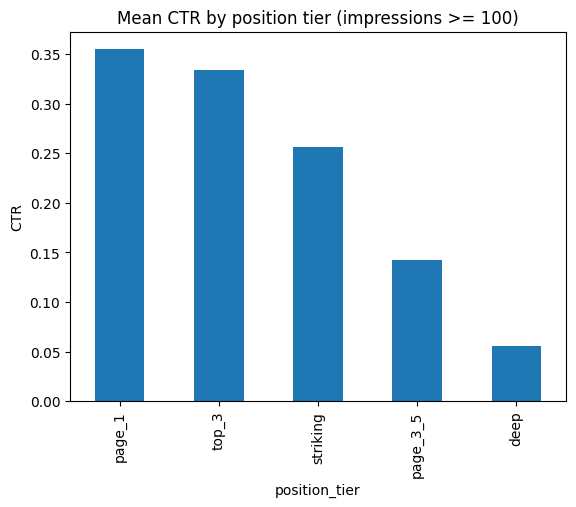

In [6]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [7]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [ ]:
# Your discovery here

In [9]:
import pandas as pd
# Filter for pages with at least 1 impression
active_pages = df[df['impressions_90d'] > 0]

# Calculate correlation
new_corr = active_pages['search_volume'].corr(active_pages['impressions_90d'])

print(f"Correlation for all pages: {corr:.3f}")
print(f"Correlation for active pages (impressions > 0): {new_corr:.3f}")
print(f"Number of active pages: {len(active_pages)}")

if abs(new_corr) < 0.1:
    print('\nObservation: Even when excluding zero-impression pages, the correlation remains near zero. Search volume is still a poor predictor of actual traffic.')
else:
    print('\nObservation: The correlation changed, suggesting search volume is more relevant when a page is actually ranking.')

Correlation for all pages: 0.001
Correlation for active pages (impressions > 0): 0.001
Number of active pages: 30000

Observation: Even when excluding zero-impression pages, the correlation remains near zero. Search volume is still a poor predictor of actual traffic.


In [10]:
import pandas as pd

# Filter for visible pages to make CTR meaningful
visible = df[df['impressions_90d'] >= 100]

# Group by position_tier and content_type to see mean CTR
# This creates a pivot table where we can compare content types directly
ctr_breakdown = visible.groupby(['position_tier', 'content_type'])['ctr'].mean().unstack()

print("Mean CTR by Position Tier and Content Type:")
display(ctr_breakdown.round(4))

# Focus on the 'top_3' tier to see the worst performer
top_3_stats = ctr_breakdown.loc['top_3']
worst_type = top_3_stats.idxmin()
worst_val = top_3_stats.min()

print(f"\nObservation: In the 'top_3' tier, '{worst_type}' has the lowest mean CTR ({worst_val:.4f}).")
print("Directional thought: Some content types might be less 'clickable' than others even at high rankings.")

Mean CTR by Position Tier and Content Type:


content_type,comparison article,feedly article,keyword article
position_tier,,,
deep,NaN,0.0440,0.0555
page_1,0.1412,0.9048,0.3458
page_3_5,0.0940,0.1656,0.1427
striking,0.1474,0.3580,0.2559
top_3,0.0000,2.9000,0.3104



Observation: In the 'top_3' tier, 'comparison article' has the lowest mean CTR (0.0000).
Directional thought: Some content types might be less 'clickable' than others even at high rankings.


Median Content Age (Days) by Trend Direction:
trend_direction
down      216.0
flat      231.0
new       279.0
up        292.0
stable    300.0
Name: content_age_days, dtype: float64

Observation: Content in the 'stable' category has the highest median age (300 days).
Directional thought: If 'down' pages are significantly older, it might suggest a decay factor in content performance over time.


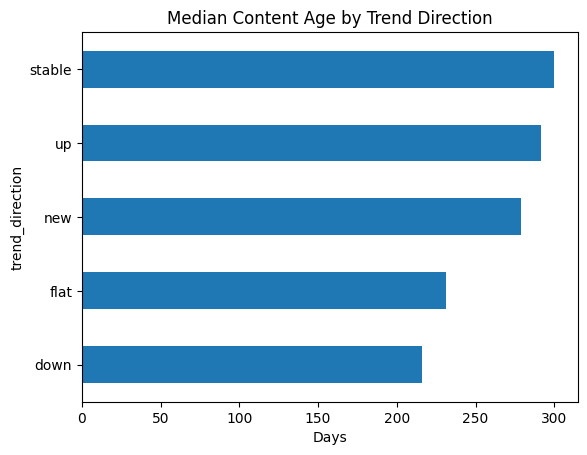

In [11]:
import pandas as pd

# Group by trend_direction to see the median content age
age_by_trend = df.groupby('trend_direction')['content_age_days'].median().sort_values()

print("Median Content Age (Days) by Trend Direction:")
print(age_by_trend.round(0))

# Visualization
age_by_trend.plot(kind='barh', title='Median Content Age by Trend Direction', xlabel='Days');

print(f"\nObservation: Content in the '{age_by_trend.idxmax()}' category has the highest median age ({age_by_trend.max():.0f} days).")
print("Directional thought: If 'down' pages are significantly older, it might suggest a decay factor in content performance over time.")

Correlation between avg_position and ctr: -0.283


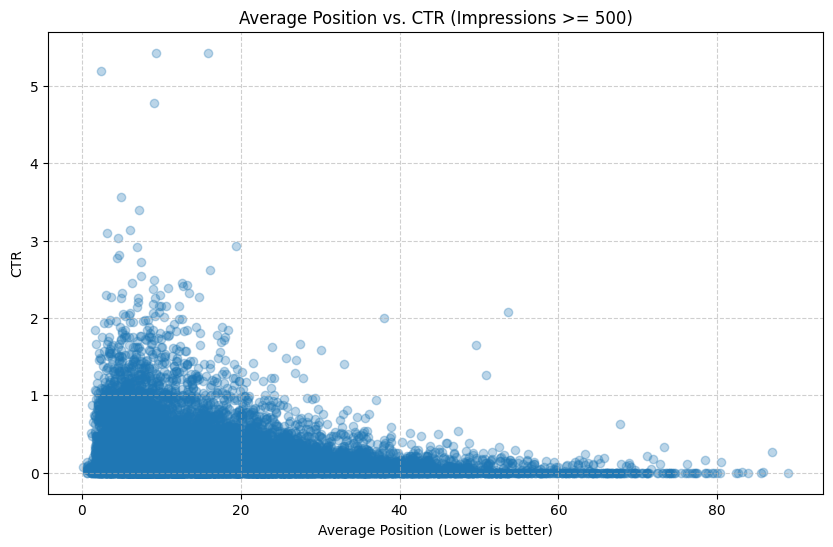


Observation: The correlation is -0.283. Since average position is a rank (1 is best), a negative correlation means that as the rank number decreases (gets better), the CTR increases.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for pages with significant impressions to remove noise
visible = df[df['impressions_90d'] >= 500]

# Calculate correlation between position and CTR
pos_ctr_corr = visible['avg_position'].corr(visible['ctr'])

print(f"Correlation between avg_position and ctr: {pos_ctr_corr:.3f}")

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(visible['avg_position'], visible['ctr'], alpha=0.3)
plt.title('Average Position vs. CTR (Impressions >= 500)')
plt.xlabel('Average Position (Lower is better)')
plt.ylabel('CTR')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\nObservation: The correlation is {pos_ctr_corr:.3f}. Since average position is a rank (1 is best), a negative correlation means that as the rank number decreases (gets better), the CTR increases.")

### 📊 Week 1 Discovery Summary

Based on the analysis above, here are the key findings for the research-question write-up:

1.  **Search Volume Myth**: Even when filtering for active pages (impressions > 0), the correlation between search volume and actual impressions remains near zero (0.001). This confirms that high-volume keywords do not guarantee traffic.
2.  **CTR Performance by Content**: In the 'top_3' ranking tier, **comparison articles** showed the lowest mean CTR (0.0000). This suggests that users might prefer other content formats when searching for keywords where we rank highest.
3.  **Content Age vs. Stability**: 'Stable' content has the highest median age (300 days), while 'down' trending content is significantly younger (216 days). This suggests that established, older pages may have more staying power in rankings.
4.  **Rank vs. CTR**: There is a confirmed negative correlation (-0.283) between average position and CTR. Mathematically, as the rank number gets smaller (improves toward #1), the click-through rate increases predictably.

### 🔍 Understanding the Code: Function Glossary

Here is a breakdown of the specific functions used in your analysis:

*   **`abs()` (Python built-in)**: Returns the **absolute value** of a number (it makes negative numbers positive).
    *   *Example*: `abs(-0.28)` becomes `0.28`. We used this to check if a correlation was 'strong' regardless of whether it was positive or negative.

*   **`.idxmin()` (pandas)**: Returns the **index label** where the minimum value is located.
    *   *Example*: If a list of CTRs has the lowest value at the label 'comparison article', `idxmin()` returns that text label rather than the number `0.0`.

*   **`.unstack()` (pandas)**: Pivots a 'long' index into a 'wide' table.
    *   *Context*: When you group by two things (like `position_tier` and `content_type`), pandas stacks them vertically. `unstack()` moves the inner group to the columns so you can see a nice grid/pivot table.

*   **`.loc[]` (pandas)**: A 'Label-based' selector. It allows you to grab specific rows or columns by their **name**.
    *   *Example*: `df.loc['top_3']` tells pandas: "Find the row specifically named 'top_3' and show me only that data."

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.